In [8]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf

In [9]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']
audiopath = train_df['path'].tolist()

audiopath[:5]

['D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

In [10]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')
# df.drop(columns=['Id', 'path', 'speakerId'], inplace=True)

train_df.head(5)

,Id,path,speakerId,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange,intention
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,change languagenone
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,activatemusic
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,deactivatelights
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume


In [5]:
# Config
SAMPLE_RATE = 16000
DURATION = 2
SAMPLES_PER_FILE = SAMPLE_RATE * DURATION
BATCH_SIZE = 32

# ----------------------------
# 1. Load Your DataFrame
# ----------------------------
# Example: train_df = pd.read_csv("metadata.csv") or already in memory
# Columns: ['path', 'intention']
paths = train_df['path'].values
labels = train_df['intention'].values

# ----------------------------
# 2. Encode Labels
# ----------------------------
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

# ----------------------------
# 3. Split Dataset
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(paths, encoded_labels, test_size=0.2, random_state=4, stratify=encoded_labels)

# ----------------------------
# 4. Audio Loader Function
# ----------------------------
def load_audio(path):
    audio, _ = librosa.load(path.decode("utf-8"), sr=SAMPLE_RATE)
    if len(audio) > SAMPLES_PER_FILE:
        audio = audio[:SAMPLES_PER_FILE]
    else:
        audio = np.pad(audio, (0, SAMPLES_PER_FILE - len(audio)))
    return audio.astype(np.float32)

def tf_audio_loader(path, label):
    audio = tf.numpy_function(load_audio, [path], tf.float32)
    audio.set_shape([SAMPLES_PER_FILE])  # very important for TF shapes
    audio = tf.expand_dims(audio, axis=-1)  # (samples, 1)
    label = tf.one_hot(label, depth=num_classes)
    return audio, label

# ----------------------------
# 5. Create tf.data.Dataset
# ----------------------------
def make_dataset(paths, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_audio_loader, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train)
val_ds = make_dataset(X_val, y_val, shuffle=False)

# ----------------------------
# 6. Define Model (Raw Audio CNN)
# ----------------------------
def build_model(input_shape=(SAMPLES_PER_FILE, 1), num_classes=7):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(16, 5, strides=2, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(32, 5, strides=2, activation='relu')(x)
    x = tf.keras.layers.Conv1D(64, 5, strides=2, activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(num_classes=num_classes)

# ----------------------------
# 7. Train
# ----------------------------
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# # ----------------------------
# # 8. Save Model + LabelEncoder
# # ----------------------------
# model.save("intent_raw_audio_model")

# import pickle
# with open("label_encoder.pkl", "wb") as f:
#     pickle.dump(label_encoder, f)

Epoch 1/10


c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


247/247 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.2644 - loss: 1.8464 - val_accuracy: 0.2882 - val_loss: 1.8012
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.2672 - loss: 1.8057 - val_accuracy: 0.2669 - val_loss: 1.7852
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.2694 - loss: 1.7834 - val_accuracy: 0.2993 - val_loss: 1.7324
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.2784 - loss: 1.7430 - val_accuracy: 0.2846 - val_loss: 1.7129
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.2928 - loss: 1.7178 - val_accuracy: 0.3014 - val_loss: 1.6817
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.3069 - loss: 1.6935 - val_accuracy: 0.3064 - val_loss: 1.6715
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 160ms/step - accuracy: 0.3117 - loss: 1.6707 - val_accuracy: 0.3349 - val_loss: 1.6356
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 40s 162ms/step - accuracy: 0.3189 - loss: 1.6454 - val

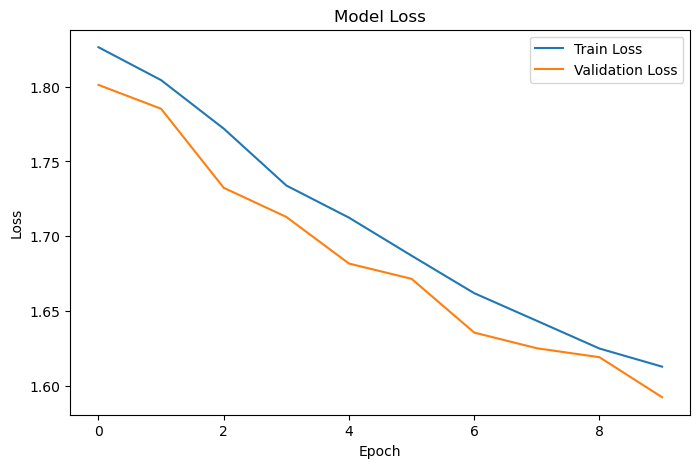

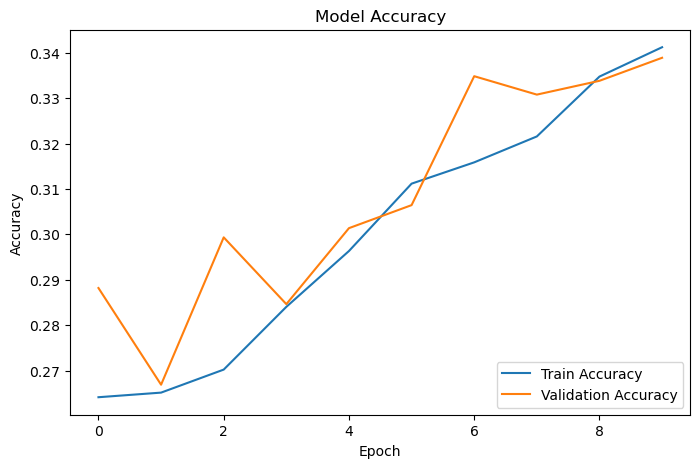

In [6]:
# Plot training & validation loss
plt.figure(figsize=(8, 5))  # Set figure size
plt.plot(history.history.get('loss', []), label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Plot training & validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history.get('accuracy', []), label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

In [11]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Config
# ----------------------------
SAMPLE_RATE = 16000
N_MELS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Your DataFrame
# ----------------------------
# Example:
# train_df = pd.read_csv("your_data.csv")
# train_df['path'] -> full .wav paths
# train_df['intention'] -> labels

label_encoder = LabelEncoder()
train_df['label_idx'] = label_encoder.fit_transform(train_df['intention'])

# ----------------------------
# Dataset Class
# ----------------------------
class AudioIntentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df['path'].tolist()
        self.labels = df['label_idx'].tolist()
        self.transform = transform

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=512,
            n_mels=N_MELS
        )

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            resample = torchaudio.transforms.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
            waveform = resample(waveform)

        mel_spec = self.mel_transform(waveform)
        mel_spec = torchaudio.functional.amplitude_to_DB(mel_spec, multiplier=10, db_multiplier=0)

        return mel_spec, label

# ----------------------------
# CNN Model for Spectrograms
# ----------------------------
class SpectrogramCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  # (B, 16, H, W)
        x = F.relu(self.conv2(x))  # (B, 32, H, W)
        x = F.relu(self.conv3(x))  # (B, 64, H, W)
        x = self.pool(x)           # (B, 64, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 64)
        return self.fc(x)

# ----------------------------
# Train and Eval Functions
# ----------------------------
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# ----------------------------
# Data Setup
# ----------------------------
train_df_split, val_df_split = train_test_split(train_df, test_size=0.2, stratify=train_df['label_idx'])

train_dataset = AudioIntentDataset(train_df_split)
val_dataset = AudioIntentDataset(val_df_split)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ----------------------------
# Train Loop
# ----------------------------
num_classes = len(label_encoder.classes_)
model = SpectrogramCNN(num_classes=num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Acc = {val_acc:.4f}")

# # Save model and encoder
# torch.save(model.state_dict(), "intent_model.pt")
# import pickle
# with open("label_encoder.pkl", "wb") as f:
#     pickle.dump(label_encoder, f)

TypeError: amplitude_to_DB() missing 1 required positional argument: 'amin'